In [3]:
# Cell 1: Setup & Library Imports
import pandas as pd
import numpy as np
from scipy import stats
import sqlite3
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.figsize'] = (12, 6)

# Directories
PROCESSED_DIR = "../data/processed"
CHARTS_DIR = "../reports/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

# Connect to DB and fetch NAV & Fund Data
conn = sqlite3.connect('../db/bluestock_mf.db')
df_nav = pd.read_sql_query("SELECT * FROM fact_nav", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

df_fund = pd.read_sql_query("SELECT amfi_code, scheme_name, expense_ratio_pct FROM dim_fund", conn)

# Load Benchmark Data
df_bench = pd.read_csv('../data/processed/clean_benchmark.csv')
df_bench['date'] = pd.to_datetime(df_bench['date'], errors='coerce')

In [6]:
# Cell 2: Task 1 - Compute daily returns for all funds
# Calculate daily return: nav_t / nav_t-1 - 1
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Calculate Annualised Return: (1 + daily_return).prod()^(252/n) - 1
def calc_annualised_return(series):
    n = len(series.dropna())
    if n == 0: return np.nan
    prod_return = (1 + series.dropna()).prod()
    return (prod_return ** (252 / n)) - 1

annualised_returns = df_nav.groupby('amfi_code')['daily_return'].apply(calc_annualised_return).reset_index()
annualised_returns.rename(columns={'daily_return': 'annualised_return_pct'}, inplace=True)
annualised_returns['annualised_return_pct'] *= 100 # Convert to percentage

# Save to CSV
df_nav[['amfi_code', 'date', 'nav', 'daily_return']].to_csv(f"{PROCESSED_DIR}/returns_computed.csv", index=False)
print("csv file with daily returns computed and saved to 'returns_computed.csv'.")

csv file with daily returns computed and saved to 'returns_computed.csv'.


In [7]:
# Task 2 - Calculate CAGR
latest_date = df_nav['date'].max()

def get_nav_on_date(df, amfi, target_date):
    # Find the closest available date on or before the target date
    subset = df[(df['amfi_code'] == amfi) & (df['date'] <= target_date)]
    if subset.empty: return np.nan
    return subset.iloc[-1]['nav']

cagr_data = []
for amfi in df_nav['amfi_code'].unique():
    nav_end = get_nav_on_date(df_nav, amfi, latest_date)
    nav_1y = get_nav_on_date(df_nav, amfi, latest_date - pd.DateOffset(years=1))
    nav_3y = get_nav_on_date(df_nav, amfi, latest_date - pd.DateOffset(years=3))
    nav_5y = get_nav_on_date(df_nav, amfi, latest_date - pd.DateOffset(years=5))
    
    cagr_1y = (nav_end / nav_1y) ** (1/1) - 1 if pd.notnull(nav_1y) else np.nan
    cagr_3y = (nav_end / nav_3y) ** (1/3) - 1 if pd.notnull(nav_3y) else np.nan
    cagr_5y = (nav_end / nav_5y) ** (1/5) - 1 if pd.notnull(nav_5y) else np.nan
    
    cagr_data.append([amfi, cagr_1y, cagr_3y, cagr_5y])

df_cagr = pd.DataFrame(cagr_data, columns=['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr'])
df_cagr.to_csv(f"{PROCESSED_DIR}/cagr_report.csv", index=False)
print("csv file with CAGR computed and saved to 'cagr_report.csv'.")

csv file with CAGR computed and saved to 'cagr_report.csv'.


In [8]:
# Tasks 3 & 4 - Sharpe and Sortino Ratios
risk_free_rate_annual = 0.065 # 6.5% RBI repo rate proxy
rf_daily = risk_free_rate_annual / 252

risk_metrics = []

for amfi, group in df_nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
        
    mean_ret = returns.mean()
    std_ret = returns.std()
    
    # Sharpe Ratio
    excess_return = mean_ret - rf_daily
    sharpe = (excess_return / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan
    
    # Sortino Ratio (Downside deviation using negative returns)
    negative_returns = returns[returns < 0]
    downside_std = negative_returns.std()
    sortino = (excess_return / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan
    
    risk_metrics.append([amfi, sharpe, sortino])

df_risk = pd.DataFrame(risk_metrics, columns=['amfi_code', 'sharpe_ratio', 'sortino_ratio'])

# Save separate CSVs as requested by rubric
df_risk[['amfi_code', 'sharpe_ratio']].to_csv(f"{PROCESSED_DIR}/sharpe_values.csv", index=False)
df_risk[['amfi_code', 'sortino_ratio']].to_csv(f"{PROCESSED_DIR}/sortino_values.csv", index=False)
print("csv files with risk metrics computed and saved.")

csv files with risk metrics computed and saved.


In [24]:
# Task 5 - Compute Alpha and Beta
# Prep Nifty 100 benchmark returns
nifty100 = df_bench[df_bench['index_name'].str.contains('NIFTY100', case=False, na=False)].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()

alpha_beta_data = []

for amfi, group in df_nav.groupby('amfi_code'):
    # Merge fund returns with benchmark returns on date
    merged = pd.merge(group[['date', 'daily_return']], nifty100[['date', 'bench_return']], on='date', how='inner').dropna()
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(merged['bench_return'], merged['daily_return'])
    beta = slope
    alpha = intercept * 252 # Annualise the daily alpha
    alpha_beta_data.append([amfi, alpha, beta])

df_ab = pd.DataFrame(alpha_beta_data, columns=['amfi_code', 'alpha', 'beta'])
df_ab.to_csv(f"{PROCESSED_DIR}/alpha_beta.csv", index=False)
print("csv file with alpha and beta computed and saved to 'alpha_beta.csv'.")  

csv file with alpha and beta computed and saved to 'alpha_beta.csv'.


In [25]:
# Task 6 - Maximum Drawdown
def calc_max_drawdown(group):
    cummax = group['nav'].cummax()
    drawdown = (group['nav'] / cummax) - 1
    max_dd = drawdown.min()
    
    # Find the date of the worst drawdown
    worst_date = group.loc[drawdown.idxmin(), 'date'] if pd.notnull(max_dd) else pd.NaT
    return pd.Series({'max_drawdown': max_dd, 'worst_dd_date': worst_date})

df_drawdown = df_nav.groupby('amfi_code').apply(calc_max_drawdown).reset_index()
df_drawdown.to_csv(f"{PROCESSED_DIR}/max_drawdown.csv", index=False)
print("csv file with maximum drawdown computed and saved to 'max_drawdown.csv'.")

csv file with maximum drawdown computed and saved to 'max_drawdown.csv'.


In [26]:
# Task 7 - Composite Fund Scorecard
# Merge all our calculated metrics together
df_score = df_fund.merge(df_cagr[['amfi_code', 'cagr_3yr']], on='amfi_code', how='left')
df_score = df_score.merge(df_risk[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
df_score = df_score.merge(df_ab[['amfi_code', 'alpha']], on='amfi_code', how='left')
df_score = df_score.merge(df_drawdown[['amfi_code', 'max_drawdown']], on='amfi_code', how='left') 

# Drop NaNs to rank fairly
df_score = df_score.dropna()

# Calculate percentile ranks (0 to 1)
# For returns, sharpe, and alpha: higher is better
rank_3yr = df_score['cagr_3yr'].rank(pct=True)
rank_sharpe = df_score['sharpe_ratio'].rank(pct=True)
rank_alpha = df_score['alpha'].rank(pct=True)

# For expense ratio and Max DD: lower (or closer to 0) is better, so we invert the rank
# Max DD is negative (e.g. -0.20 is worse than -0.05), so higher numerical value is better.
rank_exp = df_score['expense_ratio_pct'].rank(pct=True, ascending=False)
rank_dd = df_score['max_drawdown'].rank(pct=True) # Higher number (closer to 0) is better

# Apply Rubric Weights: 30% 3yr, 25% Sharpe, 20% Alpha, 15% Expense, 10% Max DD
df_score['composite_score'] = (
    (rank_3yr * 0.30) + 
    (rank_sharpe * 0.25) + 
    (rank_alpha * 0.20) + 
    (rank_exp * 0.15) + 
    (rank_dd * 0.10)
) * 100 # Scale 0 to 100

df_score = df_score.sort_values('composite_score', ascending=False)
df_score.to_csv(f"{PROCESSED_DIR}/fund_scorecard.csv", index=False)
print(f"csv file with composite fund scorecard computed and saved to 'fund_scorecard.csv'. top fund is: {df_score.iloc[0]['scheme_name']} with score {df_score.iloc[0]['composite_score']:.2f}.")

csv file with composite fund scorecard computed and saved to 'fund_scorecard.csv'. top fund is: Mirae Asset Large Cap Fund - Regular - Growth with score 86.25.


--- 3-Year Tracking Error vs Nifty 100 ---
Mirae Asset Large Cap Fund - R   : 18.77%
ICICI Pru Midcap Fund - Regula   : 23.24%
Kotak Flexicap Fund - Regular    : 20.63%
HDFC Mid-Cap Opportunities Fun   : 22.47%
ICICI Pru Bluechip Fund - Dire   : 18.72%


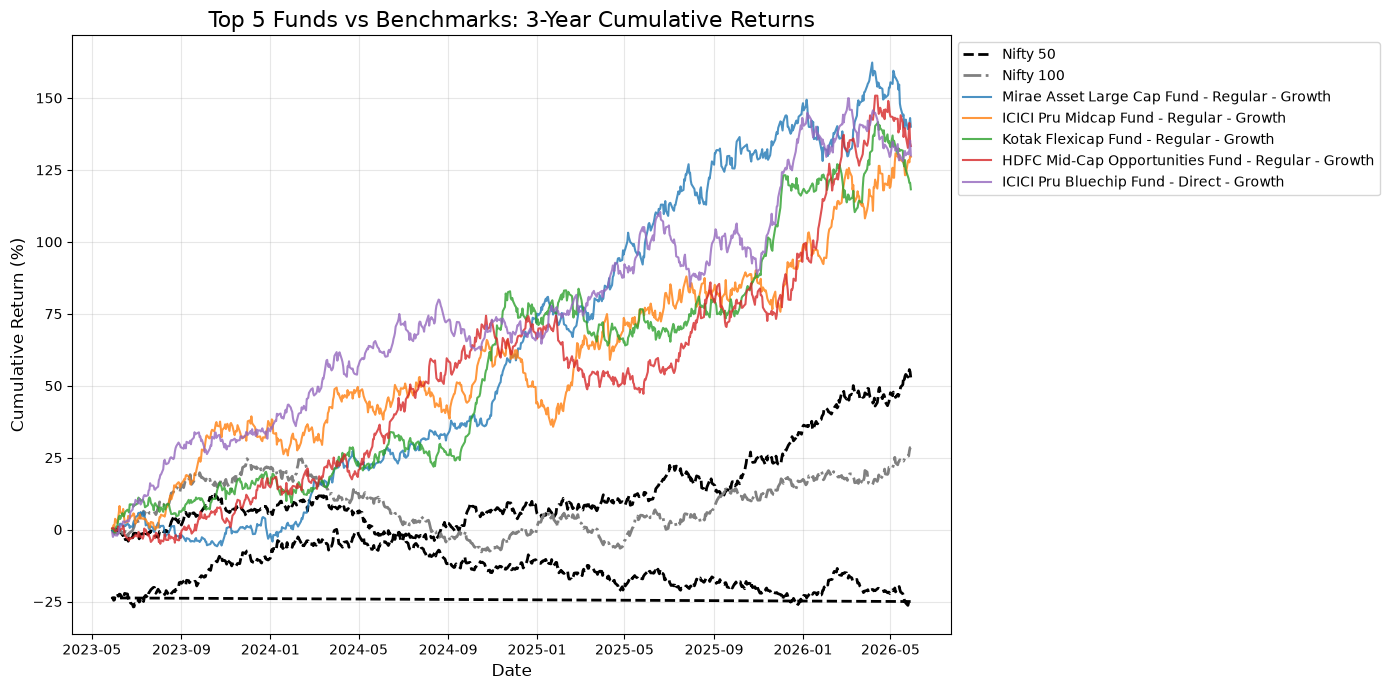

In [29]:
# Task 8 - Plot Top 5 Funds vs Benchmark
top_5_amfi = df_score.head(5)['amfi_code'].tolist()
start_date = latest_date - pd.DateOffset(years=3)

# Prep Nifty 50 and 100 data
nifty50 = df_bench[df_bench['index_name'].str.contains('NIFTY50', case=False, na=False)].copy()
nifty50 = nifty50[(nifty50['date'] >= start_date) & (nifty50['date'] <= latest_date)]
nifty50['cumulative_return'] = (1 + nifty50['close_value'].pct_change().fillna(0)).cumprod() - 1

nifty100_3y = nifty100[(nifty100['date'] >= start_date) & (nifty100['date'] <= latest_date)].copy()
nifty100_3y['cumulative_return'] = (1 + nifty100_3y['bench_return'].fillna(0)).cumprod() - 1

plt.figure(figsize=(14, 7))

# Plot Benchmarks
plt.plot(nifty50['date'], nifty50['cumulative_return'] * 100, label='Nifty 50', color='black', linewidth=2, linestyle='--')
plt.plot(nifty100_3y['date'], nifty100_3y['cumulative_return'] * 100, label='Nifty 100', color='gray', linewidth=2, linestyle='-.')

# Plot Top 5 Funds and compute Tracking Error
print("--- 3-Year Tracking Error vs Nifty 100 ---")
for amfi in top_5_amfi:
    fund_data = df_nav[(df_nav['amfi_code'] == amfi) & (df_nav['date'] >= start_date)].copy()
    fund_name = df_fund[df_fund['amfi_code'] == amfi]['scheme_name'].iloc[0]
    
    fund_data['cumulative_return'] = (1 + fund_data['daily_return'].fillna(0)).cumprod() - 1
    plt.plot(fund_data['date'], fund_data['cumulative_return'] * 100, label=fund_name, alpha=0.8)
    
    # Compute Tracking Error (Standard deviation of excess returns vs Nifty 100)
    merged_te = pd.merge(fund_data[['date', 'daily_return']], nifty100_3y[['date', 'bench_return']], on='date', how='inner').dropna()
    tracking_error = np.std(merged_te['daily_return'] - merged_te['bench_return']) * np.sqrt(252) * 100
    print(f"{fund_name[:30]:<32} : {tracking_error:.2f}%")

plt.title('Top 5 Funds vs Benchmarks: 3-Year Cumulative Returns', fontsize=16)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"{CHARTS_DIR}/08_benchmark_comparison.png", dpi=300)
plt.show()

# Close DB
conn.close()